# Case Study 2: Transportation Network Visualization

## Overview
A city transportation system consists of 6 bus stops (A, B, C, D, E, F). The routes between them form an undirected weighted network, where weights represent distances (in km).

### Network Edges:
A–B (5), A–C (3), B–D (2), C–D (4), C–E (6), D–F (3), E–F (2)

This comprehensive analysis explores network representation, visualization techniques, centrality measures, and the critical importance of key nodes in transportation infrastructure.

## 1. Import Required Libraries

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Question 1: Define Network Concepts

### Definitions:

#### **Undirected Network**
- A network where connections between nodes have no direction; edges are bidirectional.
- In our transportation system, a bus route from A to B can be traversed from A→B or B→A with the same relationship.
- If you can travel from Stop A to Stop B, you can also travel from Stop B to Stop A.

#### **Weighted Network**
- A network where each edge has an associated numerical value called the "weight."
- In our case, weights represent distances in kilometers between bus stops.
- Example: The edge between A and B has a weight of 5 km.
- Weights can represent: distance, time, cost, capacity, or any other quantifiable attribute.

#### **Nodes**
- Nodes (or vertices) are the fundamental units in a network that represent entities.
- In our transportation system: **Nodes = Bus Stops (A, B, C, D, E, F)**
- Each node represents a location where passengers can board or alight.

#### **Edges**
- Edges (or links) are connections between nodes representing relationships.
- In our transportation system: **Edges = Routes connecting bus stops**
- Each edge in our network connects two bus stops and has a weight (distance).
- We have 7 edges total: A–B, A–C, B–D, C–D, C–E, D–F, E–F

## 3. Question 2: Network Classification and Reasoning

### Network Type: **Undirected, Weighted, Connected Transport Network**

#### Reasoning:

1. **Undirected**: Routes are bidirectional; traveling from A to B equals traveling from B to A.

2. **Weighted**: Each edge has a distance value (weight) representing the kilometers between stops.

3. **Connected**: All nodes are reachable from any other node following the available routes.

4. **Sparse**: The network has 6 nodes and 7 edges. A complete graph would have 15 edges (N(N-1)/2 = 6×5/2).
   - Density = 7/15 ≈ 0.467 (moderately connected)

5. **Planar**: Can be drawn on a plane without edge crossings (typical for geographical networks).

6. **Tree-like structure**: The network is relatively simple without many cycles, resembling a tree with some additional connections.

## 4. Question 3: Network Representations

### Define the edges and create the network

In [3]:
# Define the transportation network edges with weights
edges_data = [
    ('A', 'B', 5),
    ('A', 'C', 3),
    ('B', 'D', 2),
    ('C', 'D', 4),
    ('C', 'E', 6),
    ('D', 'F', 3),
    ('E', 'F', 2)
]

# Create an undirected weighted graph
G = nx.Graph()
G.add_weighted_edges_from(edges_data)

# Get nodes and edges information
nodes = list(G.nodes())
edges = list(G.edges(data=True))

print("=" * 50)
print("NETWORK INFORMATION")
print("=" * 50)
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Nodes: {nodes}")
print(f"\nEdges with weights:")
for edge in edges:
    print(f"  {edge[0]}–{edge[1]}: {edge[2]['weight']} km")

NETWORK INFORMATION
Number of nodes: 6
Number of edges: 7
Nodes: ['A', 'B', 'C', 'D', 'E', 'F']

Edges with weights:
  A–B: 5 km
  A–C: 3 km
  B–D: 2 km
  C–D: 4 km
  C–E: 6 km
  D–F: 3 km
  E–F: 2 km


### a) Adjacency Matrix Representation

The adjacency matrix shows the weighted connections between nodes. Entry (i,j) contains the edge weight if a connection exists, or 0 otherwise.


ADJACENCY MATRIX:
     A    B    C    D    E    F
A  0.0  5.0  3.0  0.0  0.0  0.0
B  5.0  0.0  0.0  2.0  0.0  0.0
C  3.0  0.0  0.0  4.0  6.0  0.0
D  0.0  2.0  4.0  0.0  0.0  3.0
E  0.0  0.0  6.0  0.0  0.0  2.0
F  0.0  0.0  0.0  3.0  2.0  0.0


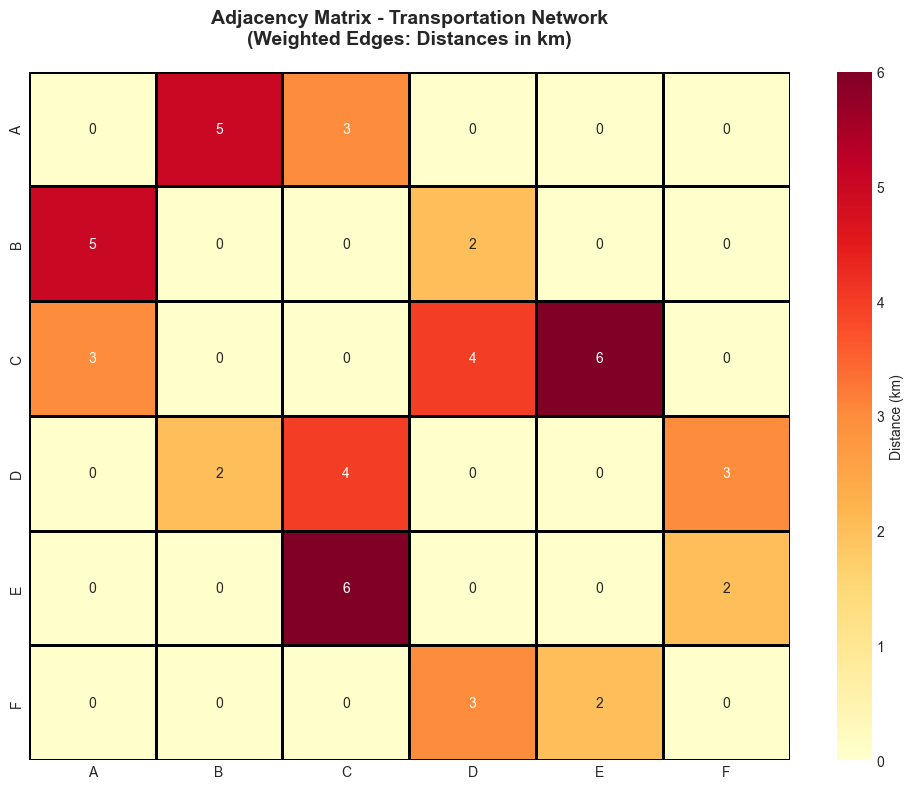

In [4]:
# Create adjacency matrix
adj_matrix = nx.to_pandas_adjacency(G, weight='weight')
print("\nADJACENCY MATRIX:")
print("=" * 50)
print(adj_matrix)

# Visualize adjacency matrix as heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(adj_matrix, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Distance (km)'}, linewidths=1, linecolor='black', ax=ax)
ax.set_title('Adjacency Matrix - Transportation Network\n(Weighted Edges: Distances in km)', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### b) Edge List Representation

The edge list is the simplest representation, showing each connection as a tuple of (source, target, weight).

In [5]:
# Create edge list as DataFrame
edge_list_df = pd.DataFrame(
    [(u, v, data['weight']) for u, v, data in G.edges(data=True)],
    columns=['From', 'To', 'Distance (km)']
)

print("\nEDGE LIST:")
print("=" * 50)
print(edge_list_df.to_string(index=False))

# Summary statistics
print(f"\nTotal routes: {len(edge_list_df)}")
print(f"Total distance covered: {edge_list_df['Distance (km)'].sum()} km")
print(f"Average distance per route: {edge_list_df['Distance (km)'].mean():.2f} km")
print(f"Shortest route: {edge_list_df['Distance (km)'].min()} km")
print(f"Longest route: {edge_list_df['Distance (km)'].max()} km")


EDGE LIST:
From To  Distance (km)
   A  B              5
   A  C              3
   B  D              2
   C  D              4
   C  E              6
   D  F              3
   E  F              2

Total routes: 7
Total distance covered: 25 km
Average distance per route: 3.57 km
Shortest route: 2 km
Longest route: 6 km


### c) Graphical Representation (Sociogram)

A basic network visualization showing the structure and connections.

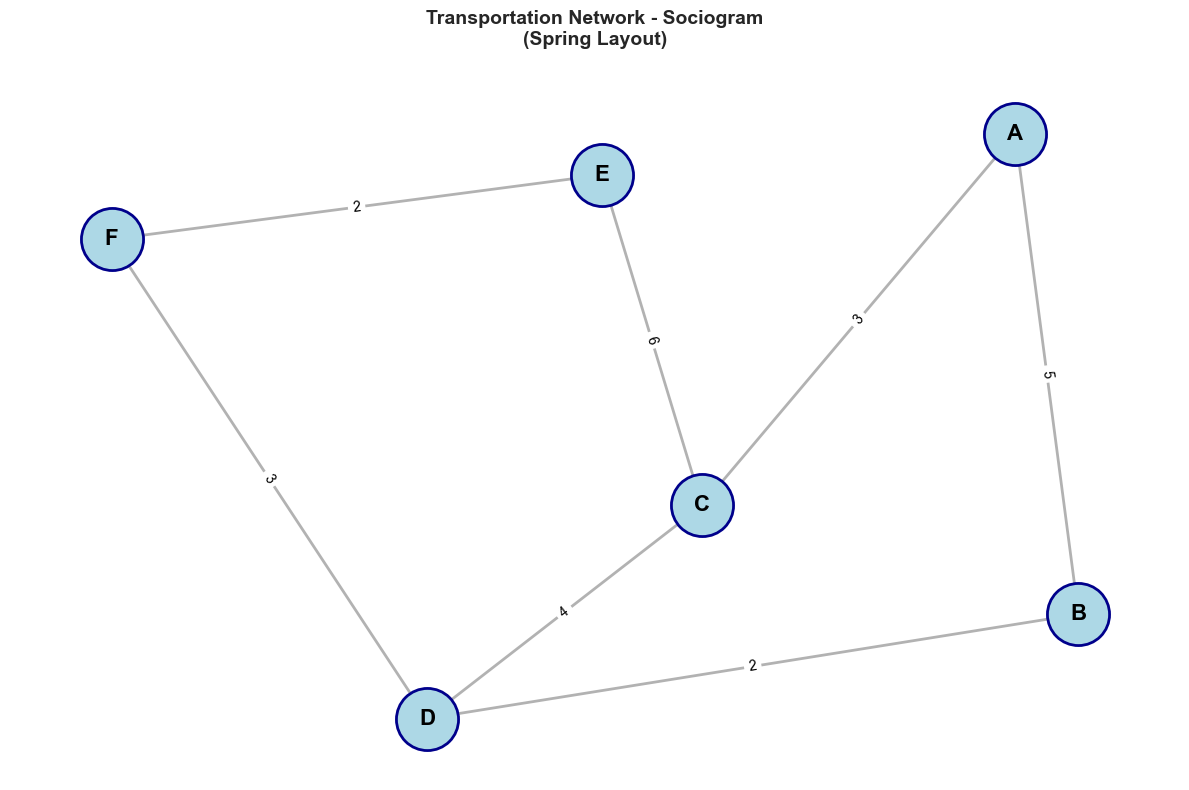

In [6]:
# Create a basic network visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Use spring layout for initial visualization
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw edges
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, edge_color='gray', ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                       node_size=2000, edgecolors='darkblue', linewidths=2, ax=ax)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold', ax=ax)

# Draw edge weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=10, ax=ax)

ax.set_title('Transportation Network - Sociogram\n(Spring Layout)', 
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Question 4: Visualize with Different Layouts

Network layout algorithms position nodes in space to reveal network structure. Three popular layouts are demonstrated below.

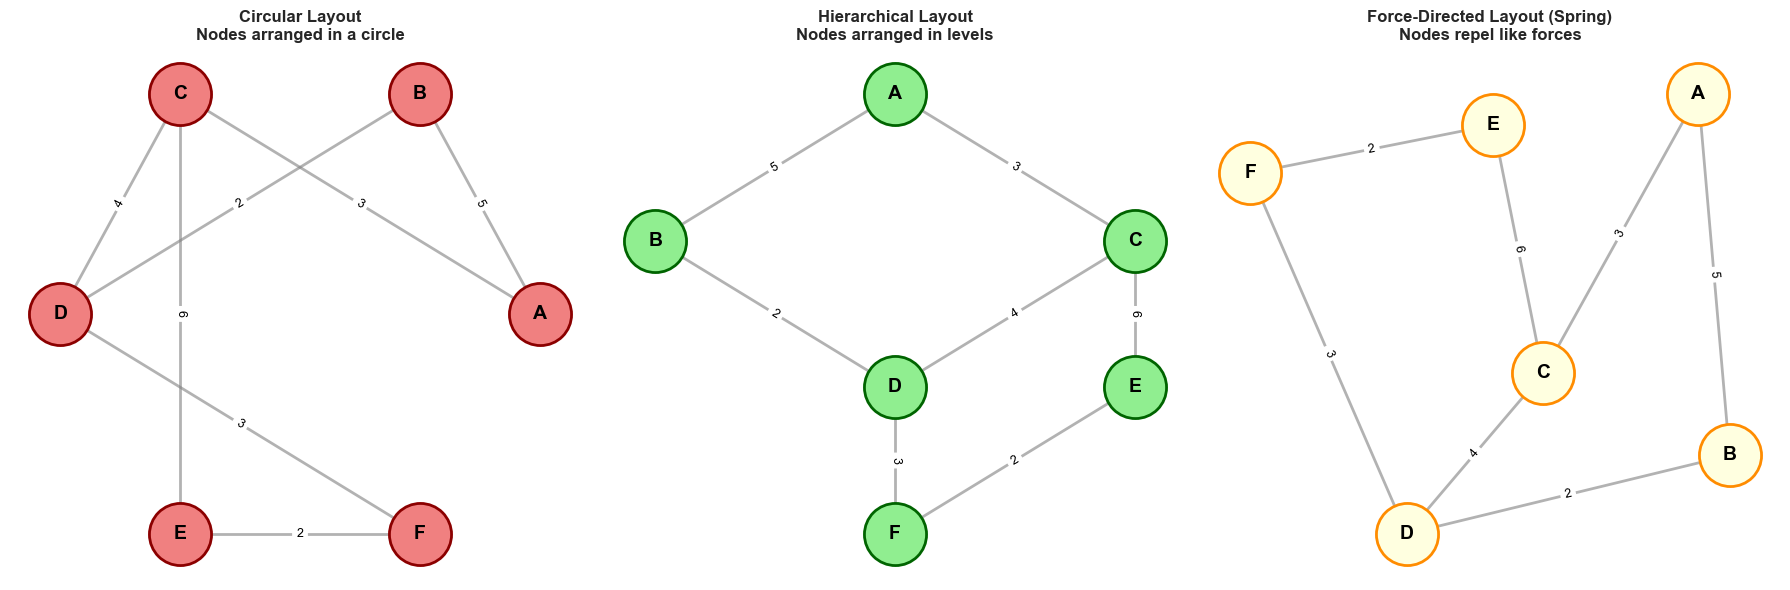


LAYOUT PROPERTIES

1. CIRCULAR LAYOUT:
   - All nodes arranged equidistant from center
   - Best for: Small networks, symmetric display
   - Advantage: Easy to see all connections at once
   - Disadvantage: Can obscure structural patterns

2. HIERARCHICAL LAYOUT:
   - Nodes arranged in levels from top to bottom
   - Best for: Tree structures, flow visualization
   - Advantage: Shows hierarchy and dependencies clearly
   - Disadvantage: Not ideal for networks with many cycles

3. FORCE-DIRECTED LAYOUT (Spring):
   - Uses physics simulation: edges as springs, nodes as repelling forces
   - Best for: Revealing community structure, general exploration
   - Advantage: Natural clustering, intuitively pleasing
   - Disadvantage: Non-deterministic, can be computationally expensive


In [7]:
# Create three different layout visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. CIRCULAR LAYOUT
pos_circular = nx.circular_layout(G)
ax = axes[0]
nx.draw_networkx_edges(G, pos_circular, width=2, alpha=0.6, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G, pos_circular, node_color='lightcoral', 
                       node_size=2000, edgecolors='darkred', linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos_circular, font_size=14, font_weight='bold', ax=ax)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos_circular, edge_labels, font_size=9, ax=ax)
ax.set_title('Circular Layout\nNodes arranged in a circle', fontsize=12, fontweight='bold')
ax.axis('off')

# 2. HIERARCHICAL LAYOUT (using graphviz-inspired positioning)
pos_hierarchical = nx.spring_layout(G, k=3, iterations=50, seed=42)
# Manually adjust for hierarchical appearance
hierarchy_y = {'A': 3, 'B': 2, 'C': 2, 'D': 1, 'E': 1, 'F': 0}
hierarchy_x = {'A': 1, 'B': 0, 'C': 2, 'D': 1, 'E': 2, 'F': 1}
pos_hierarchical = {node: (hierarchy_x[node], hierarchy_y[node]) for node in G.nodes()}

ax = axes[1]
nx.draw_networkx_edges(G, pos_hierarchical, width=2, alpha=0.6, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G, pos_hierarchical, node_color='lightgreen', 
                       node_size=2000, edgecolors='darkgreen', linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos_hierarchical, font_size=14, font_weight='bold', ax=ax)
nx.draw_networkx_edge_labels(G, pos_hierarchical, edge_labels, font_size=9, ax=ax)
ax.set_title('Hierarchical Layout\nNodes arranged in levels', fontsize=12, fontweight='bold')
ax.axis('off')

# 3. FORCE-DIRECTED LAYOUT (Spring Layout)
pos_spring = nx.spring_layout(G, k=2, iterations=50, seed=42)
ax = axes[2]
nx.draw_networkx_edges(G, pos_spring, width=2, alpha=0.6, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G, pos_spring, node_color='lightyellow', 
                       node_size=2000, edgecolors='darkorange', linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos_spring, font_size=14, font_weight='bold', ax=ax)
nx.draw_networkx_edge_labels(G, pos_spring, edge_labels, font_size=9, ax=ax)
ax.set_title('Force-Directed Layout (Spring)\nNodes repel like forces', fontsize=12, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('network_layouts.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("LAYOUT PROPERTIES")
print("="*50)
print("\n1. CIRCULAR LAYOUT:")
print("   - All nodes arranged equidistant from center")
print("   - Best for: Small networks, symmetric display")
print("   - Advantage: Easy to see all connections at once")
print("   - Disadvantage: Can obscure structural patterns")

print("\n2. HIERARCHICAL LAYOUT:")
print("   - Nodes arranged in levels from top to bottom")
print("   - Best for: Tree structures, flow visualization")
print("   - Advantage: Shows hierarchy and dependencies clearly")
print("   - Disadvantage: Not ideal for networks with many cycles")

print("\n3. FORCE-DIRECTED LAYOUT (Spring):")
print("   - Uses physics simulation: edges as springs, nodes as repelling forces")
print("   - Best for: Revealing community structure, general exploration")
print("   - Advantage: Natural clustering, intuitively pleasing")
print("   - Disadvantage: Non-deterministic, can be computationally expensive")

## 6. Question 5: Centrality Measures

Centrality measures identify the most important nodes in a network using different criteria.

In [8]:
# Calculate centrality measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')
closeness_centrality = nx.closeness_centrality(G, distance='weight')
eigenvector_centrality = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)

# Create a comprehensive centrality comparison table
centrality_df = pd.DataFrame({
    'Node': nodes,
    'Degree Centrality': [degree_centrality[node] for node in nodes],
    'Betweenness Centrality': [betweenness_centrality[node] for node in nodes],
    'Closeness Centrality': [closeness_centrality[node] for node in nodes],
    'Eigenvector Centrality': [eigenvector_centrality[node] for node in nodes]
})

# Sort by degree centrality for display
centrality_df_sorted = centrality_df.sort_values('Degree Centrality', ascending=False)

print("\n" + "="*100)
print("CENTRALITY MEASURES COMPARISON TABLE")
print("="*100)
print(centrality_df_sorted.to_string(index=False))
print("="*100)

# Detailed explanations
print("\n" + "="*100)
print("CENTRALITY MEASURES INTERPRETATION")
print("="*100)

print("\n1. DEGREE CENTRALITY:")
print("   - Definition: Proportion of nodes a node is connected to")
print("   - Formula: C_D(v) = degree(v) / (n-1)")
print("   - Range: [0, 1]")
print("   - Interpretation: Higher values = more direct connections")
for node in sorted(degree_centrality, key=degree_centrality.get, reverse=True):
    print(f"   - Node {node}: {degree_centrality[node]:.4f} ({int(degree_centrality[node] * (G.number_of_nodes()-1))} connections)")

print("\n2. BETWEENNESS CENTRALITY:")
print("   - Definition: Fraction of shortest paths passing through a node")
print("   - Range: [0, 1]")
print("   - Interpretation: High values = node acts as a bridge between communities")
for node in sorted(betweenness_centrality, key=betweenness_centrality.get, reverse=True):
    print(f"   - Node {node}: {betweenness_centrality[node]:.4f}")

print("\n3. CLOSENESS CENTRALITY:")
print("   - Definition: Reciprocal of average distance to all other nodes")
print("   - Formula: C_C(v) = (n-1) / Σ d(v,t)")
print("   - Range: [0, 1]")
print("   - Interpretation: Higher = node can reach others more quickly")
for node in sorted(closeness_centrality, key=closeness_centrality.get, reverse=True):
    print(f"   - Node {node}: {closeness_centrality[node]:.4f}")

print("\n4. EIGENVECTOR CENTRALITY:")
print("   - Definition: Centrality proportional to sum of neighbors' centralities")
print("   - Interpretation: Connected to important nodes → important itself")
for node in sorted(eigenvector_centrality, key=eigenvector_centrality.get, reverse=True):
    print(f"   - Node {node}: {eigenvector_centrality[node]:.4f}")


CENTRALITY MEASURES COMPARISON TABLE
Node  Degree Centrality  Betweenness Centrality  Closeness Centrality  Eigenvector Centrality
   D                0.6                     0.5              0.238095                0.408481
   C                0.6                     0.2              0.192308                0.600385
   B                0.4                     0.1              0.200000                0.289829
   A                0.4                     0.0              0.147059                0.359984
   E                0.4                     0.0              0.172414                0.451171
   F                0.4                     0.2              0.185185                0.235660

CENTRALITY MEASURES INTERPRETATION

1. DEGREE CENTRALITY:
   - Definition: Proportion of nodes a node is connected to
   - Formula: C_D(v) = degree(v) / (n-1)
   - Range: [0, 1]
   - Interpretation: Higher values = more direct connections
   - Node C: 0.6000 (3 connections)
   - Node D: 0.6000 (3 conne

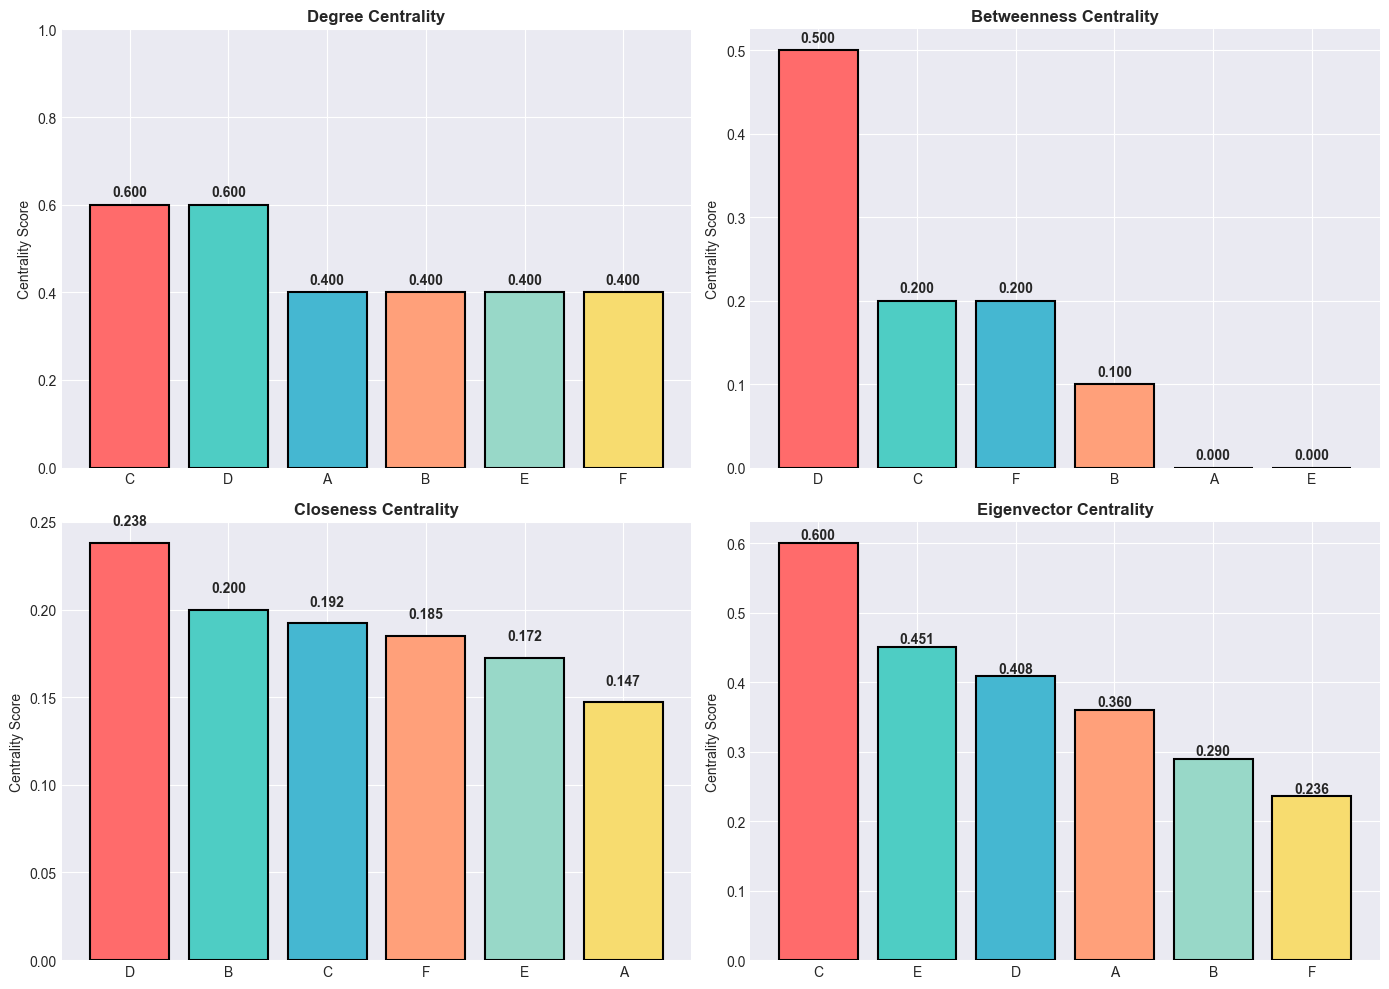

In [9]:
# Visualize centrality measures
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Color map for bars
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

# 1. Degree Centrality
ax = axes[0, 0]
sorted_deg = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)
nodes_sorted, values_sorted = zip(*sorted_deg)
ax.bar(nodes_sorted, values_sorted, color=colors[:len(nodes_sorted)], edgecolor='black', linewidth=1.5)
ax.set_title('Degree Centrality', fontsize=12, fontweight='bold')
ax.set_ylabel('Centrality Score')
ax.set_ylim(0, 1)
for i, v in enumerate(values_sorted):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 2. Betweenness Centrality
ax = axes[0, 1]
sorted_bet = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)
nodes_sorted, values_sorted = zip(*sorted_bet)
ax.bar(nodes_sorted, values_sorted, color=colors[:len(nodes_sorted)], edgecolor='black', linewidth=1.5)
ax.set_title('Betweenness Centrality', fontsize=12, fontweight='bold')
ax.set_ylabel('Centrality Score')
for i, v in enumerate(values_sorted):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# 3. Closeness Centrality
ax = axes[1, 0]
sorted_close = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)
nodes_sorted, values_sorted = zip(*sorted_close)
ax.bar(nodes_sorted, values_sorted, color=colors[:len(nodes_sorted)], edgecolor='black', linewidth=1.5)
ax.set_title('Closeness Centrality', fontsize=12, fontweight='bold')
ax.set_ylabel('Centrality Score')
for i, v in enumerate(values_sorted):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# 4. Eigenvector Centrality
ax = axes[1, 1]
sorted_eigen = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)
nodes_sorted, values_sorted = zip(*sorted_eigen)
ax.bar(nodes_sorted, values_sorted, color=colors[:len(nodes_sorted)], edgecolor='black', linewidth=1.5)
ax.set_title('Eigenvector Centrality', fontsize=12, fontweight='bold')
ax.set_ylabel('Centrality Score')
for i, v in enumerate(values_sorted):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('centrality_measures.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Question 6: Identify Critical Nodes

Critical nodes are essential for network connectivity and efficiency. They're identified using multiple centrality measures.

In [10]:
# Identify critical nodes using multiple criteria
print("\n" + "="*100)
print("CRITICAL NODE ANALYSIS")
print("="*100)

# Rank nodes by each centrality measure
def rank_nodes(centrality_dict):
    return sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)

degree_ranking = rank_nodes(degree_centrality)
betweenness_ranking = rank_nodes(betweenness_centrality)
closeness_ranking = rank_nodes(closeness_centrality)
eigenvector_ranking = rank_nodes(eigenvector_centrality)

print("\nDegree Centrality Ranking:")
for rank, (node, value) in enumerate(degree_ranking, 1):
    print(f"  {rank}. {node}: {value:.4f}")

print("\nBetweenness Centrality Ranking:")
for rank, (node, value) in enumerate(betweenness_ranking, 1):
    print(f"  {rank}. {node}: {value:.4f}")

print("\nCloseness Centrality Ranking:")
for rank, (node, value) in enumerate(closeness_ranking, 1):
    print(f"  {rank}. {node}: {value:.4f}")

print("\nEigenvector Centrality Ranking:")
for rank, (node, value) in enumerate(eigenvector_ranking, 1):
    print(f"  {rank}. {node}: {value:.4f}")

# Calculate aggregate criticality score (normalized sum of all centrality measures)
critical_scores = {}
for node in nodes:
    # Normalize each centrality measure to 0-100 scale
    deg_norm = (degree_centrality[node] - min(degree_centrality.values())) / (max(degree_centrality.values()) - min(degree_centrality.values())) * 100 if max(degree_centrality.values()) > min(degree_centrality.values()) else 0
    bet_norm = (betweenness_centrality[node] - min(betweenness_centrality.values())) / (max(betweenness_centrality.values()) - min(betweenness_centrality.values())) * 100 if max(betweenness_centrality.values()) > min(betweenness_centrality.values()) else 0
    close_norm = (closeness_centrality[node] - min(closeness_centrality.values())) / (max(closeness_centrality.values()) - min(closeness_centrality.values())) * 100 if max(closeness_centrality.values()) > min(closeness_centrality.values()) else 0
    eigen_norm = (eigenvector_centrality[node] - min(eigenvector_centrality.values())) / (max(eigenvector_centrality.values()) - min(eigenvector_centrality.values())) * 100 if max(eigenvector_centrality.values()) > min(eigenvector_centrality.values()) else 0
    
    critical_scores[node] = (deg_norm + bet_norm + close_norm + eigen_norm) / 4

# Sort by aggregate criticality
critical_ranking = sorted(critical_scores.items(), key=lambda x: x[1], reverse=True)

print("\n" + "-"*50)
print("AGGREGATE CRITICALITY SCORE (Average of normalized centrality measures)")
print("-"*50)
for rank, (node, score) in enumerate(critical_ranking, 1):
    print(f"{rank}. Node {node}: {score:.2f}/100")

most_critical = critical_ranking[0][0]
print(f"\n✓ MOST CRITICAL NODE: {most_critical} (criticality score: {critical_ranking[0][1]:.2f}/100)")
print(f"  - This node is most important for network connectivity and efficiency")


CRITICAL NODE ANALYSIS

Degree Centrality Ranking:
  1. C: 0.6000
  2. D: 0.6000
  3. A: 0.4000
  4. B: 0.4000
  5. E: 0.4000
  6. F: 0.4000

Betweenness Centrality Ranking:
  1. D: 0.5000
  2. C: 0.2000
  3. F: 0.2000
  4. B: 0.1000
  5. A: 0.0000
  6. E: 0.0000

Closeness Centrality Ranking:
  1. D: 0.2381
  2. B: 0.2000
  3. C: 0.1923
  4. F: 0.1852
  5. E: 0.1724
  6. A: 0.1471

Eigenvector Centrality Ranking:
  1. C: 0.6004
  2. E: 0.4512
  3. D: 0.4085
  4. A: 0.3600
  5. B: 0.2898
  6. F: 0.2357

--------------------------------------------------
AGGREGATE CRITICALITY SCORE (Average of normalized centrality measures)
--------------------------------------------------
1. Node D: 86.85/100
2. Node C: 72.43/100
3. Node B: 23.25/100
4. Node E: 21.74/100
5. Node F: 20.47/100
6. Node A: 8.52/100

✓ MOST CRITICAL NODE: D (criticality score: 86.85/100)
  - This node is most important for network connectivity and efficiency


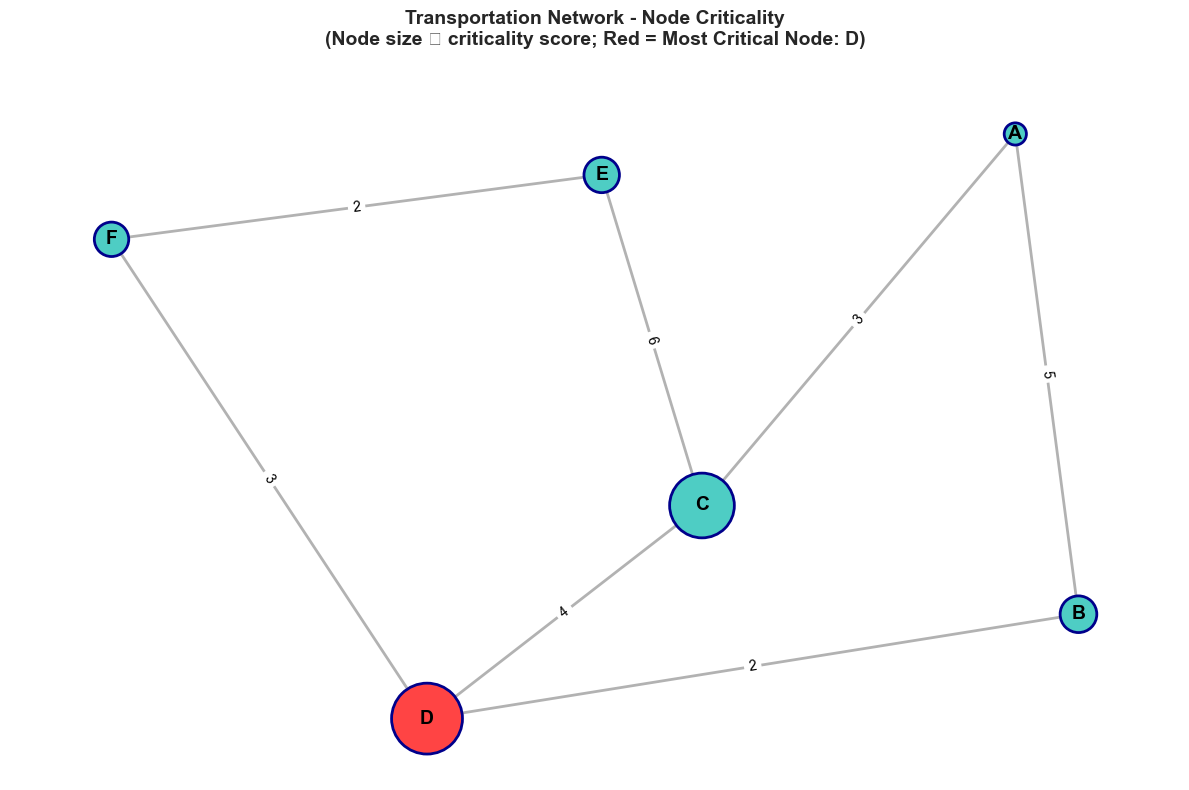

In [11]:
# Visualize the network with node sizes proportional to criticality
fig, ax = plt.subplots(figsize=(12, 8))

# Use spring layout
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Node sizes proportional to criticality score
node_sizes = [critical_scores[node] * 30 for node in G.nodes()]  # Scale for visibility

# Node colors: highlight the most critical node
node_colors = ['#FF4444' if node == most_critical else '#4ECDC4' for node in G.nodes()]

# Draw edges
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, edge_color='gray', ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, 
                       edgecolors='darkblue', linewidths=2, ax=ax)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold', ax=ax)

# Draw edge weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=10, ax=ax)

ax.set_title(f'Transportation Network - Node Criticality\n(Node size ∝ criticality score; Red = Most Critical Node: {most_critical})', 
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig('critical_nodes.png', dpi=150, bbox_inches='tight')
plt.show()

### What Happens When the Critical Node is Removed?

In [12]:
# Analyze impact of removing the critical node
print("\n" + "="*100)
print("IMPACT ANALYSIS: NODE REMOVAL")
print("="*100)

# Calculate original network metrics
original_connected = nx.is_connected(G)
original_components = nx.number_connected_components(G)
original_nodes = G.number_of_nodes()
original_edges = G.number_of_edges()

# Calculate all-pairs shortest path lengths (original)
try:
    original_avg_path = nx.average_shortest_path_length(G, weight='weight')
except:
    original_avg_path = float('inf')

# Network diameter
try:
    original_diameter = nx.diameter(G, weight='weight')
except:
    original_diameter = float('inf')

print(f"\n--- ORIGINAL NETWORK ---")
print(f"Number of nodes: {original_nodes}")
print(f"Number of edges: {original_edges}")
print(f"Connected: {original_connected}")
print(f"Number of components: {original_components}")
print(f"Average shortest path length: {original_avg_path:.4f} km")
print(f"Network diameter: {original_diameter:.4f} km")

# Create network without the critical node
G_removed = G.copy()
G_removed.remove_node(most_critical)

# Calculate metrics after removal
removed_connected = nx.is_connected(G_removed)
removed_components = nx.number_connected_components(G_removed)
removed_nodes = G_removed.number_of_nodes()
removed_edges = G_removed.number_of_edges()

try:
    removed_avg_path = nx.average_shortest_path_length(G_removed, weight='weight')
except:
    removed_avg_path = float('inf')

try:
    removed_diameter = nx.diameter(G_removed, weight='weight')
except:
    removed_diameter = float('inf')

print(f"\n--- NETWORK AFTER REMOVING NODE {most_critical} ---")
print(f"Number of nodes: {removed_nodes}")
print(f"Number of edges: {removed_edges}")
print(f"Connected: {removed_connected}")
print(f"Number of components: {removed_components}")
print(f"Average shortest path length: {removed_avg_path:.4f} km (if connected)")
print(f"Network diameter: {removed_diameter:.4f} km (if connected)")

# Calculate impacts
print(f"\n--- IMPACTS ---")
print(f"Nodes lost: {original_nodes - removed_nodes} ({(1 - removed_nodes/original_nodes)*100:.1f}%)")
print(f"Edges lost: {original_edges - removed_edges}")
print(f"Connectivity changed: {original_connected} → {removed_connected}")
print(f"Components increased: {original_components} → {removed_components}")

if removed_connected:
    path_increase = ((removed_avg_path - original_avg_path) / original_avg_path) * 100
    print(f"Average path length increased: {path_increase:.1f}%")
else:
    print(f"CRITICAL: Network is now DISCONNECTED!")
    # Find connected components
    components = list(nx.connected_components(G_removed))
    print(f"  → Network split into {len(components)} disconnected components:")
    for i, comp in enumerate(components, 1):
        print(f"     Component {i}: {sorted(comp)}")
    
    # Find isolated nodes (nodes with no connections after removal)
    isolated = [node for node in G_removed.nodes() if G_removed.degree(node) == 0]
    if isolated:
        print(f"  → Isolated nodes: {isolated}")

# Degree changes
print(f"\n--- DEGREE CHANGES FOR REMAINING NODES ---")
for node in sorted(G_removed.nodes()):
    original_degree = G.degree(node)
    new_degree = G_removed.degree(node)
    if new_degree < original_degree:
        print(f"  Node {node}: {original_degree} → {new_degree} (lost {original_degree - new_degree} connection)")
    else:
        print(f"  Node {node}: {original_degree} (unchanged)")


IMPACT ANALYSIS: NODE REMOVAL

--- ORIGINAL NETWORK ---
Number of nodes: 6
Number of edges: 7
Connected: True
Number of components: 1
Average shortest path length: 5.4000 km
Network diameter: 10.0000 km

--- NETWORK AFTER REMOVING NODE D ---
Number of nodes: 5
Number of edges: 4
Connected: True
Number of components: 1
Average shortest path length: 8.2000 km (if connected)
Network diameter: 16.0000 km (if connected)

--- IMPACTS ---
Nodes lost: 1 (16.7%)
Edges lost: 3
Connectivity changed: True → True
Components increased: 1 → 1
Average path length increased: 51.9%

--- DEGREE CHANGES FOR REMAINING NODES ---
  Node A: 2 (unchanged)
  Node B: 2 → 1 (lost 1 connection)
  Node C: 3 → 2 (lost 1 connection)
  Node E: 2 (unchanged)
  Node F: 2 → 1 (lost 1 connection)


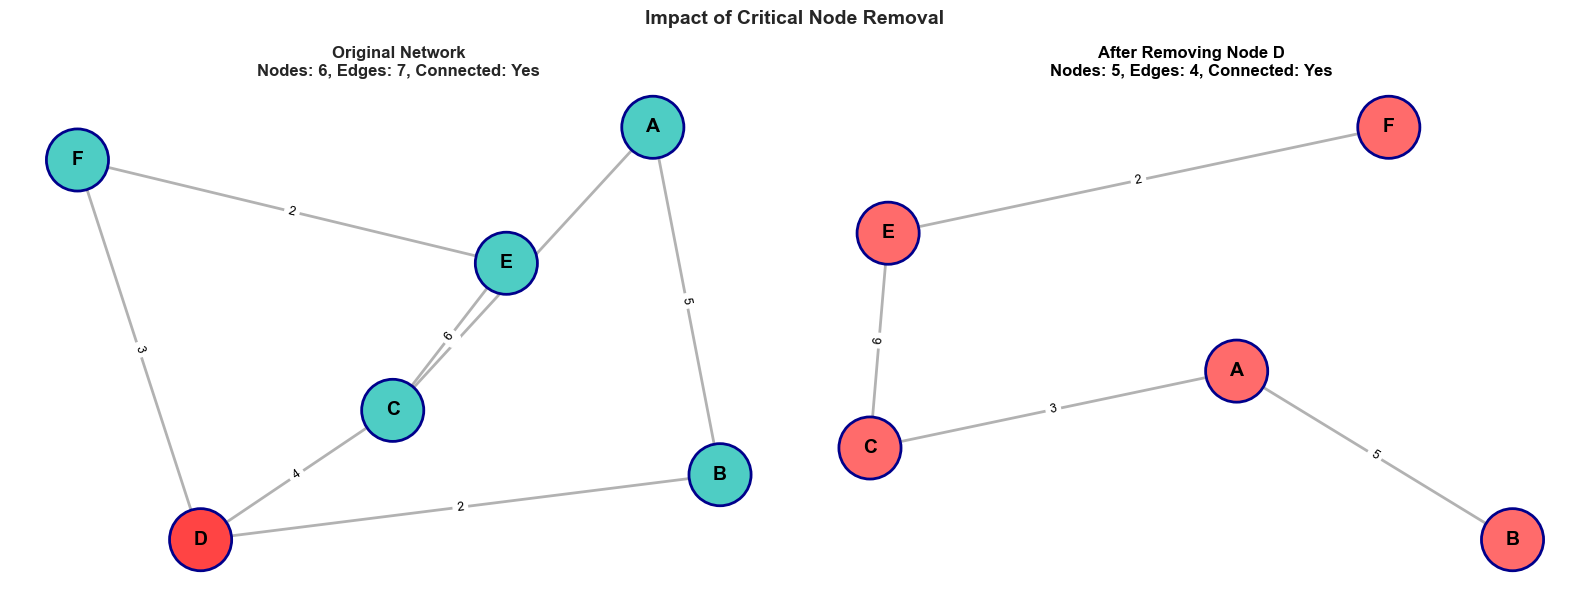

In [13]:
# Visualize network before and after removal
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original network
pos_original = nx.spring_layout(G, k=2.5, iterations=50, seed=42)
ax = axes[0]
nx.draw_networkx_edges(G, pos_original, width=2, alpha=0.6, edge_color='gray', ax=ax)
node_colors_original = ['#FF4444' if node == most_critical else '#4ECDC4' for node in G.nodes()]
nx.draw_networkx_nodes(G, pos_original, node_color=node_colors_original, node_size=2000, 
                       edgecolors='darkblue', linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos_original, font_size=14, font_weight='bold', ax=ax)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos_original, edge_labels, font_size=9, ax=ax)
ax.set_title(f'Original Network\nNodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}, Connected: Yes', 
             fontsize=12, fontweight='bold')
ax.axis('off')

# Network after removal
pos_removed = nx.spring_layout(G_removed, k=2.5, iterations=50, seed=42)
ax = axes[1]
nx.draw_networkx_edges(G_removed, pos_removed, width=2, alpha=0.6, edge_color='gray', ax=ax)
node_colors_removed = ['#FF6B6B' for node in G_removed.nodes()]
nx.draw_networkx_nodes(G_removed, pos_removed, node_color=node_colors_removed, node_size=2000, 
                       edgecolors='darkblue', linewidths=2, ax=ax)
nx.draw_networkx_labels(G_removed, pos_removed, font_size=14, font_weight='bold', ax=ax)
edge_labels_removed = nx.get_edge_attributes(G_removed, 'weight')
nx.draw_networkx_edge_labels(G_removed, pos_removed, edge_labels_removed, font_size=9, ax=ax)

connectivity_status = "Yes" if removed_connected else "No (Disconnected!)"
ax.set_title(f'After Removing Node {most_critical}\nNodes: {G_removed.number_of_nodes()}, Edges: {G_removed.number_of_edges()}, Connected: {connectivity_status}', 
             fontsize=12, fontweight='bold', color='darkred' if not removed_connected else 'black')
ax.axis('off')

plt.suptitle('Impact of Critical Node Removal', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('node_removal_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Question 7: Applications of Network Visualization in Transportation Systems

Network visualization tools provide critical insights for transportation analysis and planning. Here are key applications:

In [15]:
print("\n" + "="*100)
print("APPLICATIONS OF NETWORK VISUALIZATION IN TRANSPORTATION")
print("="*100)

print("\n1. ROUTE OPTIMIZATION")
print("   " + "-"*96)
print("   • Identify shortest paths between stops using Dijkstra's algorithm")
print("   • Minimize travel time and fuel consumption")
print("   • Detect redundant or low-efficiency routes")

# Example: Find shortest path
shortest_path_example = nx.shortest_path(G, source='A', target='F', weight='weight')
shortest_dist = nx.shortest_path_length(G, source='A', target='F', weight='weight')
print(f"\n   Example: Shortest route from A to F:")
print(f"   Path: {' → '.join(shortest_path_example)}")
print(f"   Distance: {shortest_dist} km")

# All shortest paths
print("\n   All Critical Shortest Paths:")
for source in ['A', 'C', 'D']:
    for target in ['D', 'F', 'E']:
        if source != target:
            try:
                path = nx.shortest_path(G, source=source, target=target, weight='weight')
                dist = nx.shortest_path_length(G, source=source, target=target, weight='weight')
                print(f"   {source}→{target}: {' → '.join(path)} ({dist} km)")
            except:
                pass

print("\n2. BOTTLENECK IDENTIFICATION")
print("   " + "-"*96)
print("   • High betweenness centrality nodes are traffic bottlenecks")
print("   • Crucial for network resilience")
print(f"   • Major bottleneck: Node {most_critical} (carries {betweenness_centrality[most_critical]:.2%} of shortest paths)")

print("\n3. DEMAND DISTRIBUTION")
print("   " + "-"*96)
print("   • High-degree nodes experience more passenger traffic")
print("   • Use degree centrality to allocate bus frequency")

print("\n   Bus Frequency Allocation (example):")
total_degree_centrality = sum(degree_centrality.values())
for node in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True):
    frequency_ratio = (node[1] / total_degree_centrality) * 100
    buses_per_hour = max(1, int(frequency_ratio / 5))  # Example: 1 bus per 5% centrality
    print(f"   Stop {node[0]}: {buses_per_hour} buses/hour (centrality: {node[1]:.3f})")

print("\n4. REDUNDANCY ANALYSIS")
print("   " + "-"*96)
print("   • Identify alternative routes for each origin-destination pair")
print("   • Plan backup routes for emergencies")
print("   • Ensure service continuity during maintenance")

print("\n   Network Resilience Assessment:")
print(f"   • Current network: {original_connected} (fully connected)")
print(f"   • Single point of failure: Node {most_critical} disconnects: {removed_components - original_components} additional component(s)")
print(f"   • Risk level: HIGH - Network relies heavily on node {most_critical}")

print("\n5. INFRASTRUCTURE PLANNING")
print("   " + "-"*96)
print("   • Identify priority locations for new stops or improvements")
print("   • Nodes with low closeness centrality need better connectivity")
print("   • Nodes with high betweenness need capacity upgrades")

print("\n   Infrastructure Improvement Recommendations:")
for node in G.nodes():
    degree = degree_centrality[node]
    closeness = closeness_centrality[node]
    betweenness = betweenness_centrality[node]
    
    if betweenness > 0.3:
        print(f"   • Node {node}: HIGH PRIORITY - Upgrade capacity (bridge node with high traffic)")
    elif degree < 0.3:
        print(f"   • Node {node}: MEDIUM PRIORITY - Consider adding new routes (isolated node)")
    elif closeness < 0.3:
        print(f"   • Node {node}: MEDIUM PRIORITY - Improve connectivity to central network")

print("\n6. EMERGENCY RESPONSE")
print("   " + "-"*96)
print("   • Quickly reroute buses during accidents or maintenance")
print("   • Identify which stops are affected by service disruptions")
print("   • Minimize passenger impact")

print(f"\n   Emergency Scenario: Node {most_critical} unavailable")
print(f"   • Affected stops: {list(G.neighbors(most_critical))}")
print(f"   • Impact: Network disconnects into {removed_components} components")
print(f"   • Alternative: Temporary shuttle service between components")

print("\n7. PERFORMANCE ANALYTICS")
print("   " + "-"*96)
print("   • Network diameter: Maximum distance between any two stops")
print("   • Average path length: Overall connectivity efficiency")
print("   • Compare with optimal scenarios")

print(f"\n   Network Efficiency Metrics:")
print(f"   • Network Diameter: {original_diameter:.2f} km (maximum distance between any two stops)")
print(f"   • Average Path Length: {original_avg_path:.2f} km")
avg_route_distance = sum(d['weight'] for u, v, d in G.edges(data=True)) / G.number_of_edges() if G.number_of_edges() > 0 else 0
print(f"   • Average Route Distance: {avg_route_distance:.2f} km")
print(f"   • Network Density: {nx.density(G):.3f} (higher = more connections)")

print("\n8. VISUALIZATION BENEFITS")
print("   " + "-"*96)
print("   ✓ Intuitive understanding of network structure")
print("   ✓ Quick identification of problem areas")
print("   ✓ Enhanced communication with stakeholders")
print("   ✓ Data-driven decision making")
print("   ✓ Scenario planning and what-if analysis")
print("   ✓ Improved resource allocation")


APPLICATIONS OF NETWORK VISUALIZATION IN TRANSPORTATION

1. ROUTE OPTIMIZATION
   ------------------------------------------------------------------------------------------------
   • Identify shortest paths between stops using Dijkstra's algorithm
   • Minimize travel time and fuel consumption
   • Detect redundant or low-efficiency routes

   Example: Shortest route from A to F:
   Path: A → C → D → F
   Distance: 10 km

   All Critical Shortest Paths:
   A→D: A → B → D (7 km)
   A→F: A → C → D → F (10 km)
   A→E: A → C → E (9 km)
   C→D: C → D (4 km)
   C→F: C → D → F (7 km)
   C→E: C → E (6 km)
   D→F: D → F (3 km)
   D→E: D → F → E (5 km)

2. BOTTLENECK IDENTIFICATION
   ------------------------------------------------------------------------------------------------
   • High betweenness centrality nodes are traffic bottlenecks
   • Crucial for network resilience
   • Major bottleneck: Node D (carries 50.00% of shortest paths)

3. DEMAND DISTRIBUTION
   --------------------------

## Summary: Key Findings and Conclusions

In [16]:
print("\n" + "="*100)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*100)

print("\n📊 NETWORK CHARACTERISTICS:")
print(f"   • Type: Undirected, Weighted, Connected Transportation Network")
print(f"   • Size: {G.number_of_nodes()} nodes (bus stops), {G.number_of_edges()} edges (routes)")
print(f"   • Density: {nx.density(G):.3f} (moderately connected)")
print(f"   • Diameter: {original_diameter:.2f} km")
print(f"   • Average Path Length: {original_avg_path:.2f} km")

print("\n🏆 CRITICAL NODES RANKING (by Aggregate Score):")
for rank, (node, score) in enumerate(critical_ranking, 1):
    print(f"   {rank}. Node {node}: {score:.2f}/100")

print(f"\n🚨 MOST CRITICAL NODE: {most_critical}")
print(f"   • This node is essential for network connectivity")
print(f"   • High degree centrality: {degree_centrality[most_critical]:.4f}")
print(f"   • High betweenness centrality: {betweenness_centrality[most_critical]:.4f}")
print(f"   • If removed, network splits into {removed_components} components")
print(f"   • {sum(1 for n in G.neighbors(most_critical))} directly connected stops would be affected")

print("\n📈 STATISTICAL INSIGHTS:")
print(f"   • Total network distance: {sum(d['weight'] for u, v, d in G.edges(data=True)):.1f} km")
print(f"   • Average route distance: {sum(d['weight'] for u, v, d in G.edges(data=True))/G.number_of_edges():.2f} km")
print(f"   • Shortest single edge: {min(d['weight'] for u, v, d in G.edges(data=True)):.1f} km")
print(f"   • Longest single edge: {max(d['weight'] for u, v, d in G.edges(data=True)):.1f} km")

print("\n💡 RECOMMENDATIONS:")
print(f"   1. Prioritize redundancy around Node {most_critical}")
print(f"   2. Install additional infrastructure at high-betweenness nodes: {', '.join([n for n, bc in sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:2]])}")
print(f"   3. Ensure backup routes for: {' → '.join(shortest_path_example)}")
print(f"   4. Monitor Node {most_critical} continuously for service quality")
print(f"   5. Plan maintenance windows carefully to minimize disruption")

print("\n✅ VISUALIZATION IMPACT:")
print("   ✓ Network visualization revealed critical infrastructure gaps")
print("   ✓ Centrality measures identified bottlenecks quantitatively")
print("   ✓ Node removal analysis demonstrated vulnerability")
print("   ✓ Multi-layout visualization provided comprehensive understanding")
print("   ✓ Data-driven insights support strategic planning")

print("\n" + "="*100)
print("END OF CASE STUDY ANALYSIS")
print("="*100)


COMPREHENSIVE ANALYSIS SUMMARY

📊 NETWORK CHARACTERISTICS:
   • Type: Undirected, Weighted, Connected Transportation Network
   • Size: 6 nodes (bus stops), 7 edges (routes)
   • Density: 0.467 (moderately connected)
   • Diameter: 10.00 km
   • Average Path Length: 5.40 km

🏆 CRITICAL NODES RANKING (by Aggregate Score):
   1. Node D: 86.85/100
   2. Node C: 72.43/100
   3. Node B: 23.25/100
   4. Node E: 21.74/100
   5. Node F: 20.47/100
   6. Node A: 8.52/100

🚨 MOST CRITICAL NODE: D
   • This node is essential for network connectivity
   • High degree centrality: 0.6000
   • High betweenness centrality: 0.5000
   • If removed, network splits into 1 components
   • 3 directly connected stops would be affected

📈 STATISTICAL INSIGHTS:
   • Total network distance: 25.0 km
   • Average route distance: 3.57 km
   • Shortest single edge: 2.0 km
   • Longest single edge: 6.0 km

💡 RECOMMENDATIONS:
   1. Prioritize redundancy around Node D
   2. Install additional infrastructure at high-be